In [1]:
import numpy as np
import json

from sklearn.datasets import make_multilabel_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

import plotly.graph_objects as go
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd

In [130]:
def reader(path_params):
    with open(path_params, "r") as file:
        params = json.load(file)
    print(params)
    return params

In [131]:
def generate_data_set(params):
    inputs_, outputs_ = make_multilabel_classification(
        n_samples=params["sample_size"] + 1,
        n_features=params["feature_number"],
        n_classes=params["label_number"],
        n_labels=params["avg_label_number"],
        allow_unlabeled=False,
        return_indicator=True,
    )
    return inputs_, outputs_

In [132]:
def resample_data_set(inputs_, outputs_, params):
    sample_size = inputs_.shape[0] - 1
    indices = np.arange(sample_size + 1)
    np.random.shuffle(indices)

    inputs_ = inputs_[indices, :]
    outputs_ = outputs_[indices, :]

    inputs, outputs = (inputs_[:-1, :], outputs_[:-1, :])
    input_test, output_test = (
        inputs_[-1, :].reshape(1, -1),
        outputs_[-1, :].reshape(1, -1),
    )

    inputs_train, inputs_calibration, outputs_train, outputs_calibration = (
        train_test_split(inputs, outputs, test_size=params["cal_size"])
    )

    input_scaler = StandardScaler()
    scaled_inputs_train = input_scaler.fit_transform(inputs_train)
    scaled_inputs_calibration = input_scaler.transform(inputs_calibration)
    scaled_input_test = input_scaler.transform(input_test)

    (
        scaled_inputs_selection,
        scaled_inputs_proper_cal,
        outputs_selection,
        outputs_proper_cal,
    ) = train_test_split(
        scaled_inputs_calibration,
        outputs_calibration,
        test_size=params["proper_cal_size"],
    )

    return (
        (scaled_inputs_train, outputs_train),
        (scaled_inputs_calibration, outputs_calibration),
        (
            scaled_inputs_selection,
            scaled_inputs_proper_cal,
            outputs_selection,
            outputs_proper_cal,
        ),
        (scaled_input_test, output_test),
    )

## FNR risk

In [133]:
def make_FNR_lower_empirical_risk(outputs, probas):
    sample_size = outputs.shape[0]
    def FNR_lower_empirical_risk(order):
        tmp = (
            (np.logical_and(outputs, probas < 1 - order)).sum(axis=1)
            / outputs.sum(axis=1)
        ).sum()
        return (0.0 + tmp) / (sample_size + 1)

    return FNR_lower_empirical_risk

In [134]:
def make_FNR_upper_empirical_risk(outputs, probas):
    sample_size = outputs.shape[0]
    def FNR_upper_empirical_risk(order):
        tmp = (
            (np.logical_and(outputs, probas < 1 - order)).sum(axis=1)
            / outputs.sum(axis=1)
        ).sum()
        return (1.0 + tmp) / (sample_size + 1)

    return FNR_upper_empirical_risk

In [135]:
def make_FNR_empirical_risk(outputs, probas):
    def FNR_empirical_risk(order):
        return (
            (np.logical_and(outputs, probas < 1 - order)).sum(axis=1)
            / outputs.sum(axis=1)
        ).mean()

    return FNR_empirical_risk

## Level search

In [136]:
def dichotomy_search(func, change_points):
    cardinal = change_points.shape[0]
    left_index = 0
    right_index = cardinal - 1

    f_right = func(change_points[right_index])
    f_left = func(change_points[left_index])

    if f_right * f_left > 0:
        if f_left > 0:
            return right_index
        else:
            return left_index

    while (right_index - left_index) >= 2:
        middle_index = max(
            min(np.int64((left_index + right_index) / 2), right_index), left_index
        )
        f_middle = func(change_points[middle_index])

        if (f_middle == 0) or (f_left * f_middle < 0):
            right_index = middle_index
            f_right = f_middle
        else:
            left_index = middle_index
            f_left = f_middle

    if f_left * f_right < 0:
        return right_index
    else:
        return left_index

## Size function

In [137]:
def size_function(probas, order):
    return (probas >= 1 - order).sum(axis=1).mean()

# One repetition of conformal risk-control

In [138]:
params_global = reader("params/synthetic.json")

{'data': {'sample_size': 500, 'feature_number': 300, 'label_number': 10, 'avg_label_number': 4, 'cal_size': 0.3, 'proper_cal_size': 0.5}, 'predictor': {'log_lam_min': -2, 'log_lam_max': 4, 'lam_base': 10, 'lam_number': 200}, 'risk': {'control_level': 0.25}}


In [139]:
inputs_, outputs_ = generate_data_set(params_global["data"])

In [140]:
lam = 10

In [141]:
(
    (scaled_inputs_train, outputs_train),
    (scaled_inputs_calibration, outputs_calibration),
    (
        scaled_inputs_selection,
        scaled_inputs_proper_cal,
        outputs_selection,
        outputs_proper_cal,
    ),
    (scaled_input_test, output_test),
) = resample_data_set(inputs_, outputs_, params_global["data"])

In [142]:
scaled_inputs_train.shape

(350, 300)

In [143]:
active_feature_number = np.max([1, np.int64(params_global["data"]["feature_number"] / 10)])

In [144]:
feature_set = np.arange(params_global["data"]["feature_number"])
print(feature_set)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

In [145]:
predictor_index_set = []
for _ in range(params_global["predictor"]["lam_number"]):
    feature_set = np.arange(params_global["data"]["feature_number"])
    np.random.shuffle(feature_set)
    predictor_index_set.append(
        feature_set[:active_feature_number].copy()
    )

In [146]:
predictors = [OneVsRestClassifier(LogisticRegression(C=1 / lam)) for _ in range(params_global["predictor"]["lam_number"])]

In [147]:
for predictor, active_feature in zip(predictors, predictor_index_set):
    predictor.fit(scaled_inputs_train[:, active_feature], outputs_train)

In [148]:
probas_calibration_per_predictor = [
    predictor.predict_proba(scaled_inputs_calibration[:, active_feature]) for predictor, active_feature in zip(predictors, predictor_index_set)
]

probas_selection_per_predictor = [
    predictor.predict_proba(scaled_inputs_selection[:, active_feature]) for predictor, active_feature in zip(predictors, predictor_index_set)
]
proba_test_per_predictor = [
    predictor.predict_proba(scaled_input_test[:, active_feature]) for predictor, active_feature in zip(predictors, predictor_index_set)
]

## Oracle sizes

In [149]:
def compute_order(
    risk, risk_control_level, change_points
):
    index = dichotomy_search(
        lambda q: (risk(q) - risk_control_level), change_points
    )
    return change_points[index]

In [150]:
oracle_risk_per_predictor = [
    make_FNR_empirical_risk(
        np.concatenate((outputs_calibration, output_test)),
        np.concatenate((probas_calibration, proba_test)),
    )
    for probas_calibration, proba_test in zip(
        probas_calibration_per_predictor, proba_test_per_predictor
    )
]
oracle_change_points_per_predictor = [
    np.concatenate(
        (
            [0.0],
            np.sort(1 - (np.concatenate((probas_calibration, proba_test))).flatten()),
            [1.0],
        )
    )
    for probas_calibration, proba_test in zip(
        probas_calibration_per_predictor, proba_test_per_predictor
    )
]
oracle_order_per_predictor = [
    compute_order(
        risk, params_global["risk"]["control_level"], change_points
    )
    for risk, change_points in zip(
        oracle_risk_per_predictor, oracle_change_points_per_predictor
    )
]
oracle_size_per_predictor = [
    size_function(np.concatenate((probas_calibration, proba_test)), order)
    for probas_calibration, proba_test, order in zip(
        probas_calibration_per_predictor,
        proba_test_per_predictor,
        oracle_order_per_predictor,
    )
]

## Upper and lower sizes

In [151]:
lower_risk_per_predictor = [
    make_FNR_lower_empirical_risk(outputs_calibration, probas_calibration)
    for probas_calibration in probas_calibration_per_predictor
]
change_points_per_predictor = [
    np.concatenate(
        (
            [0.0],
            np.sort(1 - probas_calibration.flatten()),
            [1.0],
        )
    )
    for probas_calibration in probas_calibration_per_predictor
]

In [152]:
lower_order_per_predictor = [
    compute_order(
        risk, params_global["risk"]["control_level"], change_points
    )
    for risk, change_points in zip(lower_risk_per_predictor, change_points_per_predictor)
]
lower_size_per_predictor = [
    size_function(np.concatenate((probas_calibration, proba_test)), order)
    for probas_calibration, proba_test, order in zip(
        probas_calibration_per_predictor,
        proba_test_per_predictor,
        lower_order_per_predictor,
    )
]

In [153]:
upper_risk_per_predictor = [
    make_FNR_upper_empirical_risk(outputs_calibration, probas_calibration)
    for probas_calibration in probas_calibration_per_predictor
]

In [154]:
upper_order_per_predictor = [
    compute_order(
        risk, params_global["risk"]["control_level"], change_points
    )
    for risk, change_points in zip(upper_risk_per_predictor, change_points_per_predictor)
]
upper_size_per_predictor = [
    size_function(np.concatenate((probas_calibration, proba_test)), order)
    for probas_calibration, proba_test, order in zip(
        probas_calibration_per_predictor,
        proba_test_per_predictor,
        upper_order_per_predictor,
    )
]

## Form split

In [155]:
selection_risk_per_predictor = [
    make_FNR_upper_empirical_risk(outputs_selection, probas_selection)
    for probas_selection in probas_selection_per_predictor
]
selection_change_points_per_predictor = [
    np.concatenate(
        (
            [0.0],
            np.sort(1 - probas_selection.flatten()),
            [1.0],
        )
    )
    for probas_selection in probas_selection_per_predictor
]

selection_upper_order_per_predictor = [
    compute_order(
        risk, params_global["risk"]["control_level"], change_points
    )
    for risk, change_points in zip(
        selection_risk_per_predictor, selection_change_points_per_predictor
    )
]

selection_upper_size_per_predictor = [
    size_function(probas_selection, order)
    for probas_selection, order in zip(
        probas_selection_per_predictor, selection_upper_order_per_predictor
    )
]

## Oracle prediction set

In [156]:
oracle_predictor_index = np.argmin(oracle_size_per_predictor)
oracle_prediction_set = np.int64(
    proba_test_per_predictor[oracle_predictor_index]
    >= 1 - oracle_order_per_predictor[oracle_predictor_index]
)

In [157]:
oracle_size = oracle_prediction_set.sum(axis=1).item()
oracle_fnr_test = (
    np.logical_and(output_test, np.logical_not(oracle_prediction_set)).sum(axis=1)
    / output_test.sum(axis=1)
).item()
print("Control level: {}".format(params_global["risk"]["control_level"]))
print("Oracle FNR: {}.".format(oracle_fnr_test))
print("Oracle size: {}.".format(oracle_size))
print("Output size: {}.".format(output_test.sum()))
print(oracle_prediction_set)
print(output_test)

Control level: 0.25
Oracle FNR: 0.0.
Oracle size: 4.
Output size: 1.
[[1 1 0 0 0 0 0 1 0 1]]
[[0 0 0 0 0 0 0 0 0 1]]


## Upper prediction set

In [158]:
proba_test_per_predictor[0]

array([[0.64744145, 0.82362474, 0.15499145, 0.48210679, 0.29965603,
        0.55106205, 0.26676104, 0.60901274, 0.03972102, 0.67652661]])

In [159]:
min_upper_size = np.min(upper_size_per_predictor)
optimal_predictor_index_set = np.arange(params_global["predictor"]["lam_number"])[
    lower_size_per_predictor <= min_upper_size
]
upper_prediction_set = np.int64(
    [
        np.min(
            [
                size_function(
                    np.concatenate(
                        (
                            probas_calibration_per_predictor[predictor_index],
                            proba_test_per_predictor[predictor_index],
                        )
                    ),
                    1 - proba_test_per_predictor[predictor_index][0, k],
                )
                for predictor_index in optimal_predictor_index_set
            ]
        )
        <= min_upper_size
        for k in range(params_global["data"]["label_number"])
    ]
).reshape(1, -1)

In [160]:
upper_size = upper_prediction_set.sum(axis=1).item()
upper_fnr_test = (
    np.logical_and(output_test, np.logical_not(upper_prediction_set)).sum(axis=1)
    / output_test.sum(axis=1)
).item()
print("Control level: {}".format(params_global["risk"]["control_level"]))
print("Upper FNR: {}.".format(upper_fnr_test))
print("Upper size: {}.".format(upper_size))
print("Output size: {}.".format(output_test.sum()))
print(upper_prediction_set)
print(output_test)

Control level: 0.25
Upper FNR: 0.0.
Upper size: 5.
Output size: 1.
[[1 1 0 1 0 0 0 1 0 1]]
[[0 0 0 0 0 0 0 0 0 1]]


## Prediction set from split

In [161]:
split_predictor_index = np.argmin(selection_upper_size_per_predictor)

probas_proper_cal = predictors[split_predictor_index].predict_proba(
    scaled_inputs_proper_cal[:, predictor_index_set[split_predictor_index]]
)

proper_cal_upper_risk = make_FNR_upper_empirical_risk(
    outputs_proper_cal, probas_proper_cal
)

proper_cal_change_points = np.concatenate(
    (
        [0.0],
        np.sort(1 - probas_proper_cal.flatten()),
        [1.0],
    )
)

proper_cal_upper_order = compute_order(
    proper_cal_upper_risk, params_global["risk"]["control_level"],
    proper_cal_change_points
)
split_prediction_set = np.int64(
    proba_test_per_predictor[split_predictor_index] >= 1 - proper_cal_upper_order
)

In [162]:
split_size = split_prediction_set.sum(axis=1).item()
split_fnr_test = (
    np.logical_and(output_test, np.logical_not(split_prediction_set)).sum(axis=1)
    / output_test.sum(axis=1)
).item()
print("Control level: {}".format(params_global["risk"]["control_level"]))
print("Split FNR: {}.".format(split_fnr_test))
print("Split size: {}.".format(split_size))
print("Output size: {}.".format(output_test.sum()))
print(split_prediction_set)
print(output_test)

Control level: 0.25
Split FNR: 0.0.
Split size: 5.
Output size: 1.
[[1 1 0 1 0 0 0 1 0 1]]
[[0 0 0 0 0 0 0 0 0 1]]


# Multiple repetitions of conformal risk-control

In [163]:
def compute_oracle_prediction_set(
    outputs_calibration,
    probas_calibration_per_predictor,
    output_test,
    proba_test_per_predictor,
    risk_control_level,
):
    oracle_risk_per_predictor = [
        make_FNR_empirical_risk(
            np.concatenate((outputs_calibration, output_test)),
            np.concatenate((probas_calibration, proba_test)),
        )
        for probas_calibration, proba_test in zip(
            probas_calibration_per_predictor, proba_test_per_predictor
        )
    ]
    oracle_change_points_per_predictor = [
        np.concatenate(
            (
                [0.0],
                np.sort(1 - (np.concatenate((probas_calibration, proba_test))).flatten()),
                [1.0],
            )
        )
        for probas_calibration, proba_test in zip(
            probas_calibration_per_predictor, proba_test_per_predictor
        )
    ]
    oracle_order_per_predictor = [
        compute_order(
            risk, risk_control_level, change_points
        )
        for risk, change_points in zip(
            oracle_risk_per_predictor, oracle_change_points_per_predictor
        )
    ]
    oracle_size_per_predictor = [
        size_function(np.concatenate((probas_calibration, proba_test)), order)
        for probas_calibration, proba_test, order in zip(
            probas_calibration_per_predictor,
            proba_test_per_predictor,
            oracle_order_per_predictor,
        )
    ]

    oracle_predictor_index = np.argmin(oracle_size_per_predictor)
    oracle_prediction_set = np.int64(
        proba_test_per_predictor[oracle_predictor_index]
        >= 1 - oracle_order_per_predictor[oracle_predictor_index]
    )
    return oracle_prediction_set

In [164]:
def compute_upper_prediction_set(
    outputs_calibration,
    probas_calibration_per_predictor,
    proba_test_per_predictor,
    risk_control_level,
):
    change_points_per_predictor = [
        np.concatenate(
            (
                [0.0],
                np.sort(1 - probas_calibration.flatten()),
                [1.0],
            )
        )
        for probas_calibration in probas_calibration_per_predictor
    ]
 
    lower_risk_per_predictor = [
        make_FNR_lower_empirical_risk(outputs_calibration, probas_calibration)
        for probas_calibration in probas_calibration_per_predictor
    ]
    lower_order_per_predictor = [
        compute_order(
            risk, params_global["risk"]["control_level"], change_points
        )
        for risk, change_points in zip(lower_risk_per_predictor, change_points_per_predictor)
    ]
    lower_size_per_predictor = [
        size_function(np.concatenate((probas_calibration, proba_test)), order)
        for probas_calibration, proba_test, order in zip(
            probas_calibration_per_predictor,
            proba_test_per_predictor,
            lower_order_per_predictor,
        )
    ]

    upper_risk_per_predictor = [
        make_FNR_upper_empirical_risk(outputs_calibration, probas_calibration)
        for probas_calibration in probas_calibration_per_predictor
    ]
    upper_order_per_predictor = [
        compute_order(
            risk, params_global["risk"]["control_level"], change_points
        )
        for risk, change_points in zip(upper_risk_per_predictor, change_points_per_predictor)
    ]
    upper_size_per_predictor = [
        size_function(np.concatenate((probas_calibration, proba_test)), order)
        for probas_calibration, proba_test, order in zip(
            probas_calibration_per_predictor,
            proba_test_per_predictor,
            upper_order_per_predictor,
        )
    ]

    min_upper_size = np.min(upper_size_per_predictor)
    predictor_index_set = np.arange(lam_grid.shape[0])[
        lower_size_per_predictor <= min_upper_size
    ]
    upper_prediction_set = np.int64(
        [
            np.min(
                [
                    size_function(
                        np.concatenate(
                            (
                                probas_calibration_per_predictor[predictor_index],
                                proba_test_per_predictor[predictor_index],
                            )
                        ),
                        1 - proba_test_per_predictor[predictor_index][0, k],
                    )
                    for predictor_index in predictor_index_set
                ]
            )
            <= min_upper_size
            for k in range(params_global["data"]["label_number"])
        ]
    ).reshape(1, -1)

    return upper_prediction_set

In [165]:
def select_predictor_index(outputs_selection, probas_selection_per_predictor, risk_control_level):
    selection_change_points_per_predictor = [
        np.concatenate(
            (
                [0.0],
                np.sort(1 - probas_selection.flatten()),
                [1.0],
            )
        )
        for probas_selection in probas_selection_per_predictor
    ]

    selection_risk_per_predictor = [
        make_FNR_upper_empirical_risk(outputs_selection, probas_selection)
        for probas_selection in probas_selection_per_predictor
    ]
    selection_upper_order_per_predictor = [
        compute_order(
            risk, params_global["risk"]["control_level"], change_points
        )
        for risk, change_points in zip(
            selection_risk_per_predictor, selection_change_points_per_predictor
        )
    ]
    selection_upper_size_per_predictor = [
        size_function(probas_selection, order)
        for probas_selection, order in zip(
            probas_selection_per_predictor, selection_upper_order_per_predictor
        )
    ]

    predictor_index = np.argmin(selection_upper_size_per_predictor)
    return predictor_index

In [166]:
def compute_prediction_set(
    predictor, inputs_calibration, output_calibrations, input_test, risk_control_level
):
    probas_calibration = predictor.predict_proba(inputs_calibration)
    change_points = np.concatenate(
        (
            [0.0],
            np.sort(1 - probas_calibration.flatten()),
            [1.0],
        )
    )
    
    upper_risk = make_FNR_upper_empirical_risk(output_calibrations, probas_calibration)
    upper_order = compute_order(
        upper_risk, risk_control_level, change_points
    )

    proba_test = predictor.predict_proba(input_test)
    prediction_set = np.int64(proba_test >= 1 - upper_order)

    return prediction_set

In [176]:
lam_grid = np.logspace(
    params_global["predictor"]["log_lam_min"],
    params_global["predictor"]["log_lam_max"],
    params_global["predictor"]["lam_number"],
)
predictors = [OneVsRestClassifier(LogisticRegression(C=1 / lam)) for lam in lam_grid]

rep_number = 200

In [177]:
results = {
    "size":{
        "Oracle":[],
        "Upper":[],
        "Split":[],
        "Output":[],
    }, "FNR":{
        "Oracle":[],
        "Upper":[],
        "Split":[],
    }
}

In [ ]:
for rep_index in tqdm(range(rep_number)):
    inputs_, outputs_ = generate_data_set(params_global["data"])

    (
        (scaled_inputs_train, outputs_train),
        (scaled_inputs_calibration, outputs_calibration),
        (
            scaled_inputs_selection,
            scaled_inputs_proper_cal,
            outputs_selection,
            outputs_proper_cal,
        ),
        (scaled_input_test, output_test),
    ) = resample_data_set(inputs_, outputs_, params_global["data"])


    for predictor, active_feature in zip(predictors, predictor_index_set):
        predictor.fit(scaled_inputs_train[:, active_feature], outputs_train)


    probas_calibration_per_predictor = [
        predictor.predict_proba(scaled_inputs_calibration[:, active_feature]) for predictor, active_feature in zip(predictors, predictor_index_set)
    ]
    proba_test_per_predictor = [
        predictor.predict_proba(scaled_input_test[:, active_feature]) for predictor, active_feature in zip(predictors, predictor_index_set)
    ]
    oracle_prediction_set = compute_oracle_prediction_set(
        outputs_calibration,
        probas_calibration_per_predictor,
        output_test,
        proba_test_per_predictor,
        params_global["risk"]["control_level"],
    )

    
    upper_prediction_set = compute_upper_prediction_set(
        outputs_calibration,
        probas_calibration_per_predictor,
        proba_test_per_predictor,
        params_global["risk"]["control_level"],
    )



    probas_selection_per_predictor = [
        predictor.predict_proba(scaled_inputs_selection[:, active_feature]) for predictor, active_feature in zip(predictors, predictor_index_set)
    ]
    split_predictor_index = select_predictor_index(
        outputs_selection, probas_selection_per_predictor, params_global["risk"]["control_level"]
    )
    split_prediction_set = compute_prediction_set(
        predictors[split_predictor_index], scaled_inputs_proper_cal[:, predictor_index_set[split_predictor_index]],
        outputs_proper_cal, scaled_input_test[:, predictor_index_set[split_predictor_index]], params_global["risk"]["control_level"]
    )

    oracle_fnr = (
        np.logical_and(output_test, np.logical_not(oracle_prediction_set)).sum(axis=1)
        / output_test.sum(axis=1)
    ).item()
    upper_fnr = (
        np.logical_and(output_test, np.logical_not(upper_prediction_set)).sum(axis=1)
        / output_test.sum(axis=1)
    ).item()
    split_fnr = (
        np.logical_and(output_test, np.logical_not(split_prediction_set)).sum(axis=1)
        / output_test.sum(axis=1)
    ).item()
    
    results["FNR"]["Oracle"].append(oracle_fnr)
    results["FNR"]["Upper"].append(upper_fnr)
    results["FNR"]["Split"].append(split_fnr)

    results["size"]["Oracle"].append(oracle_prediction_set.sum())
    results["size"]["Upper"].append(upper_prediction_set.sum())
    results["size"]["Split"].append(split_prediction_set.sum())
    results["size"]["Output"].append(output_test.sum())

    
    print("Average oracle prediction-set size: {}".format(np.mean(results["size"]["Oracle"])))
    print("Average output size: {}".format(np.mean(results["size"]["Output"])))
    print("Average split prediction-set size: {}".format(np.mean(results["size"]["Split"])))
    print("Average upper prediction-set size: {}".format(np.mean(results["size"]["Upper"])))


  0%|          | 1/200 [00:07<24:26,  7.37s/it]

Average oracle prediction-set size: 7.0
Average output size: 3.0
Average split prediction-set size: 7.0
Average upper prediction-set size: 7.0


  1%|          | 2/200 [00:14<23:56,  7.26s/it]

Average oracle prediction-set size: 6.0
Average output size: 2.5
Average split prediction-set size: 6.0
Average upper prediction-set size: 7.0


  2%|▏         | 3/200 [00:21<23:19,  7.10s/it]

...

Average oracle prediction-set size: 5.0875
Average output size: 4.0875
Average split prediction-set size: 5.625
Average upper prediction-set size: 6.3125


 40%|████      | 81/200 [09:50<14:15,  7.19s/it]

Average oracle prediction-set size: 5.08641975308642
Average output size: 4.061728395061729
Average split prediction-set size: 5.617283950617284
Average upper prediction-set size: 6.296296296296297


 41%|████      | 82/200 [09:58<14:10,  7.21s/it]

Average oracle prediction-set size: 5.085365853658536
Average output size: 4.073170731707317
Average split prediction-set size: 5.634146341463414
Average upper prediction-set size: 6.2926829268292686


In [170]:
print("Average oracle prediction-set size: {}".format(np.mean(results["size"]["Oracle"])))
print("Average output size: {}".format(np.mean(results["size"]["Output"])))
print("Average split prediction-set size: {}".format(np.mean(results["size"]["Split"])))
print("Average upper prediction-set size: {}".format(np.mean(results["size"]["Upper"])))

Average oracle prediction-set size: 5.31
Average output size: 3.66
Average split prediction-set size: 5.52
Average upper prediction-set size: 6.49


In [171]:
df_volume = pd.DataFrame.from_dict(
    results["size"]
)

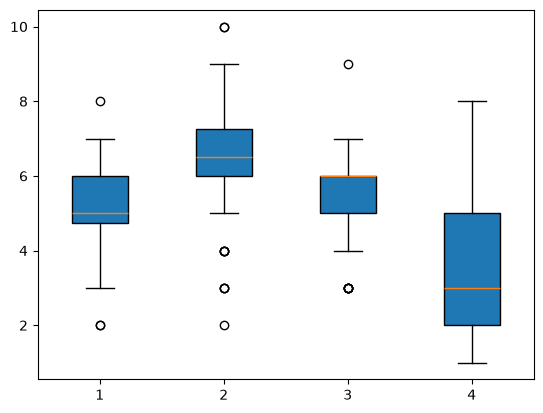

In [172]:
fig, ax = plt.subplots()
box = ax.boxplot(df_volume, patch_artist=True)

In [173]:
print("Average oracle prediction-set FNR: {}".format(np.mean(results["FNR"]["Oracle"])))
print("Average split prediction-set FNR: {}".format(np.mean(results["FNR"]["Split"])))
print("Average upper prediction-set FNR: {}".format(np.mean(results["FNR"]["Upper"])))

Average oracle prediction-set FNR: 0.23871428571428574
Average split prediction-set FNR: 0.28064285714285714
Average upper prediction-set FNR: 0.17135714285714287


In [174]:
df_fnr = pd.DataFrame.from_dict(
    results["FNR"]
)

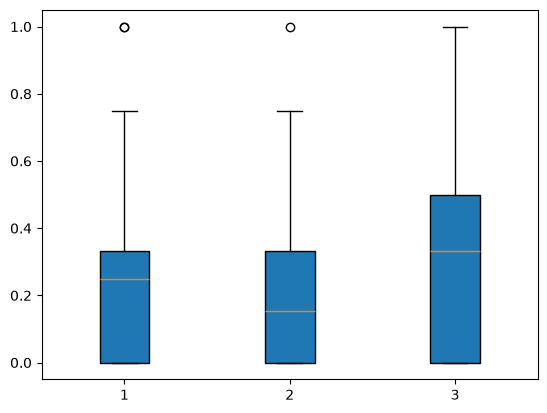

In [175]:
fig, ax = plt.subplots()
box = ax.boxplot(df_fnr, patch_artist=True)